<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_10/Day_2/Exercises%20/Exercise_xp_w10_d2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercises XP
====

**Exercise 1: Calculating Required Sample Size**

You are planning an A/B test to evaluate the impact of a new email subject line on the open rate. Based on past data, you expect a small effect size of 0.3 (an increase from 20% to 23% in the open rate). You aim for an 80% chance (power = 0.8) of detecting this effect if it exists, with a 5% significance level (α = 0.05).

Calculate the required sample size per group using Python’s statsmodels library.

What sample size is needed for each group to ensure your test is properly powered?

In [1]:
import statsmodels.stats.api as sms

# 1. Define the experiment parameters
baseline_rate = 0.20  # 20% current open rate
expected_rate = 0.23  # 23% target open rate
alpha = 0.05          # 5% Significance level (Type I error)
power = 0.80          # 80% Statistical power (1 - Type II error)

# 2. Calculate Cohen's h effect size for two proportions
effect_size = sms.proportion_effectsize(baseline_rate, expected_rate)

# 3. Calculate required sample size per group
sample_size_calculator = sms.NormalIndPower()
required_sample_size = sample_size_calculator.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1.0,          # 1:1 allocation ratio between Group A and Group B
    alternative='two-sided'
)

# 4. Display the result rounded up to the nearest integer
import math
required_n = math.ceil(required_sample_size)

print(f"Calculated Effect Size (Cohen's h): {abs(effect_size):.4f}")
print(f"Required Sample Size per group: {required_n:,}")
print(f"Total Sample Size needed (Group A + B): {required_n * 2:,}")

Calculated Effect Size (Cohen's h): 0.0731
Required Sample Size per group: 2,941
Total Sample Size needed (Group A + B): 5,882


**Exercise 2: Understanding the Relationship Between Effect Size and Sample Size**

Using the same A/B test setup as in Exercise 1, you want to explore how changing the expected effect size impacts the required sample size.

- Calculate the required sample size for the following effect sizes: 0.2, 0.4, and 0.5, keeping the significance level and power the same.

- How does the sample size change as the effect size increases? Explain why this happens.


In [2]:
import math
import statsmodels.stats.api as sms

# Fixed parameters
baseline_rate = 0.20
alpha = 0.05
power = 0.80

# Target rates corresponding to absolute increases / relative changes
target_rates = {
    "Small Effect (+2% -> 22%)": 0.22,
    "Medium Effect (+4% -> 24%)": 0.24,
    "Large Effect (+6% -> 26%)": 0.26,
    "Very Large Effect (+10% -> 30%)": 0.30
}

calculator = sms.NormalIndPower()

print(f"{'Target Open Rate':<30} | {'Cohen\'s h':<10} | {'Sample Size per Group':<20}")
print("-" * 68)

for label, target in target_rates.items():
    effect_size = sms.proportion_effectsize(baseline_rate, target)
    n = calculator.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative='two-sided'
    )
    print(f"{label:<30} | {abs(effect_size):<10.4f} | {math.ceil(n):<20,}")

Target Open Rate               | Cohen's h  | Sample Size per Group
--------------------------------------------------------------------
Small Effect (+2% -> 22%)      | 0.0491     | 6,508               
Medium Effect (+4% -> 24%)     | 0.0967     | 1,681               
Large Effect (+6% -> 26%)      | 0.1428     | 770                 
Very Large Effect (+10% -> 30%) | 0.2320     | 292                 


**Exercise 3: Exploring the Impact of Statistical Power**

Imagine you are conducting an A/B test where you expect a small effect size of 0.2. You initially plan for a power of 0.8 but wonder how increasing or decreasing the desired power level impacts the required sample size.

Calculate the required sample size for power levels of 0.7, 0.8, and 0.9, keeping the effect size at 0.2 and significance level at 0.05.

Question: How does the required sample size change with different levels of statistical power?
 Why is this understanding important when designing A/B tests?

In [3]:
import math
import statsmodels.stats.api as sms

# Given parameters
effect_size = 0.2  # Cohen's h = 0.2
alpha = 0.05       # 5% Significance level
power_levels = [0.7, 0.8, 0.9]

calculator = sms.NormalIndPower()

print(f"{'Power Level':<15} | {'Type II Error (β)':<20} | {'Sample Size per Group':<22}")
print("-" * 65)

for power in power_levels:
    beta = 1 - power
    n = calculator.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1.0,
        alternative='two-sided'
    )
    print(f"{power * 100:.0f}% ({power:<4.1f}){'':<7} | {beta * 100:.0f}% ({beta:<4.1f}){'':<10} | {math.ceil(n):<22,}")

Power Level     | Type II Error (β)    | Sample Size per Group 
-----------------------------------------------------------------
70% (0.7 )        | 30% (0.3 )           | 309                   
80% (0.8 )        | 20% (0.2 )           | 393                   
90% (0.9 )        | 10% (0.1 )           | 526                   


**Exercise 4: Implementing Sequential Testing**

You are running an A/B test on two versions of a product page to increase the purchase rate. You plan to monitor the results weekly and stop the test early if one version shows a significant improvement.

Define your stopping criteria.
Decide how you would implement sequential testing in this scenario.
At the end of week three, Version B has a p-value of 0.02. What would you do next?

**Implementing Sequential Testing**

## 1. Stopping Criteria Definition
To avoid the **peeking problem** (inflating the false-positive rate $\alpha$ by checking results continuously), we apply pre-defined **alpha spending boundaries**:

* **O’Brien-Fleming Bounds:** Uses conservative significance thresholds in early looks ($\alpha_1 \approx 0.0005$, $\alpha_2 \approx 0.004$, $\alpha_3 \approx 0.018$) and approaches standard levels at the final look.
* **Pocock Bounds:** Uses a constant, lower threshold across all interim checks ($\alpha_k \approx 0.018$).

---

## 2. Implementation Strategy
1. **Determine Maximum Sample Size ($N_{max}$):** Calculate standard sample size and apply an inflation factor ($\sim 2\text{--}8\%$) to account for multiple evaluation looks.
2. **Set Fixed Interim Schedule:** Evaluate data at predetermined checkpoints (e.g., weekly across 4 weeks).
3. **Evaluate against Boundaries:** Compare the test statistic at each look against the pre-specified alpha boundary.

---

## 3. Week 3 Scenario Analysis ($p = 0.02$)

* **O’Brien-Fleming Boundary ($\alpha_3 \approx 0.0184$):** Since $p = 0.02 > 0.0184$, the result is **not statistically significant** for an early stop. **Decision:** Continue the test into Week 4.
* **Pocock Boundary ($\alpha_3 \approx 0.0182$):** Since $p = 0.02 > 0.0182$, it still fails the threshold. **Decision:** Continue the test into Week 4.
* **Fixed-Horizon Test (No boundaries set):** Unadjusted peeking invalidates standard $p < 0.05$. **Decision:** Continue collecting data until the full target sample size is reached.

In [4]:
import numpy as np
import statsmodels.stats.weightstats as st

# Parameters
k_design = 4       # Total planned weekly checks
alpha_total = 0.05 # Overall desired Type I error rate

# Example using Pocock and O'Brien-Fleming critical alpha bounds for 4 looks:
# Reference critical p-value thresholds for a 4-look sequential test:
obrien_fleming_bounds = [0.0001, 0.0039, 0.0184, 0.0412]
pocock_bounds         = [0.0182, 0.0182, 0.0182, 0.0182]

p_val_week3 = 0.02

print("=== Sequential Testing Decision (Week 3) ===")
print(f"Observed p-value at Week 3: {p_val_week3}")
print("-" * 45)

# Evaluate against O'Brien-Fleming Look 3 threshold
of_thresh = obrien_fleming_bounds[2]
print(f"O'Brien-Fleming Week 3 Boundary: p < {of_thresh}")
if p_val_week3 < of_thresh:
    print("-> Result: Reject Null Hypothesis. STOP test early and launch Version B.")
else:
    print("-> Result: Do NOT stop early. CONTINUE test to Week 4.")

print("-" * 45)

# Evaluate against Pocock Look 3 threshold
pocock_thresh = pocock_bounds[2]
print(f"Pocock Week 3 Boundary: p < {pocock_thresh}")
if p_val_week3 < pocock_thresh:
    print("-> Result: Reject Null Hypothesis. STOP test early and launch Version B.")
else:
    print("-> Result: Do NOT stop early. CONTINUE test to Week 4.")

=== Sequential Testing Decision (Week 3) ===
Observed p-value at Week 3: 0.02
---------------------------------------------
O'Brien-Fleming Week 3 Boundary: p < 0.0184
-> Result: Do NOT stop early. CONTINUE test to Week 4.
---------------------------------------------
Pocock Week 3 Boundary: p < 0.0182
-> Result: Do NOT stop early. CONTINUE test to Week 4.


**Exercise 5: Applying Bayesian A/B Testing**

You’re testing a new feature in your app, and you want to use a Bayesian approach. Initially, you believe the new feature has a 50% chance of improving user engagement. After collecting data, your analysis suggests a 65% probability that the new feature is better.

Describe how you would set up your prior belief.
After collecting data, how does the updated belief (posterior distribution) influence your decision?
What would you do if the posterior probability was only 55%?

**Applying Bayesian A/B Testing**

## 1. Setting Up the Prior Belief
In Bayesian A/B testing for binary outcomes (e.g., engagement rate/conversion), we model success probabilities using a **Beta distribution** $\text{Beta}(\alpha, \beta)$:
* **Prior Formulation:** To represent a neutral belief with a 50% chance of improving user engagement (or a expected conversion rate around 50%), we set equal shape parameters ($\alpha_0 = \beta_0$).
* **Uninformative / Weak Prior:** A distribution such as $\text{Beta}(1, 1)$ (Uniform) or a weakly informative prior like $\text{Beta}(10, 10)$ centers belief at 50% while allowing incoming data to dominate the posterior update quickly.

---

## 2. Decision Making with a 65% Posterior Probability
* **Interpretation:** After updating the prior with observed data, the posterior distribution indicates a **65% chance that Variant B outperforms Variant A** ($\mathcal{P}(B > A) = 0.65$).
* **Business Decision:**
  * A 65% certainty is relatively weak (35% risk of implementing an inferior variant).
  * **Action:** Do not launch the feature yet. Continue data collection to narrow the posterior distribution and increase confidence, or evaluate the **Expected Loss** (risk of lost engagement) before committing.

---

## 3. Decision Strategy if Posterior Probability is 55%
* **Interpretation:** A 55% probability indicates that the performance of Variant B is almost indistinguishable from Variant A (near 50/50 toss-up).
* **Business Decision:**
  * **Action:** **Do not launch.** Roll back Variant B or keep Variant A as the default.
  * **Trade-off Analysis:** Changing codebases introduces technical debt and deployment risks. A weak 5% edge ($55\%$ probability) does not justify the engineering costs or potential unexpected regressions.

Calculated Probability that B is better than A: 94.53%


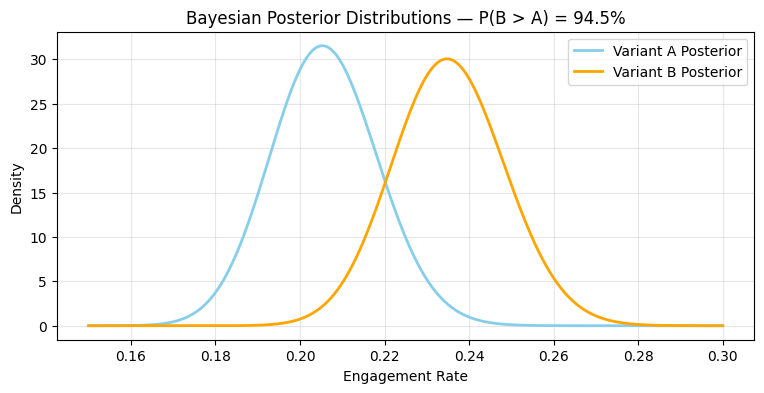

In [5]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Prior parameters (Beta prior centered around equal probability)
alpha_prior, beta_prior = 10, 10

# 2. Simulated data updates (Successes = Engagement, Trials = Total Users)
# Variant A: 200 successes out of 1000 users
a_successes, a_trials = 200, 1000
# Variant B: 230 successes out of 1000 users
b_successes, b_trials = 230, 1000

# 3. Compute Posterior Distributions (Beta-Binomial Conjugacy)
a_post = stats.beta(alpha_prior + a_successes, beta_prior + (a_trials - a_successes))
b_post = stats.beta(alpha_prior + b_successes, beta_prior + (b_trials - b_successes))

# 4. Monte Carlo simulation to find P(B > A)
samples = 100_000
a_samples = a_post.rvs(samples)
b_samples = b_post.rvs(samples)
prob_b_better = np.mean(b_samples > a_samples)

print(f"Calculated Probability that B is better than A: {prob_b_better * 100:.2f}%")

# Plot Posteriors
x = np.linspace(0.15, 0.30, 500)
plt.figure(figsize=(9, 4))
plt.plot(x, a_post.pdf(x), label="Variant A Posterior", color="skyblue", lw=2)
plt.plot(x, b_post.pdf(x), label="Variant B Posterior", color="orange", lw=2)
plt.title(f"Bayesian Posterior Distributions — P(B > A) = {prob_b_better * 100:.1f}%")
plt.xlabel("Engagement Rate")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Exercise 6: Implementing Adaptive Experimentation**

You’re running a test with three different website layouts to increase user engagement. Initially, each layout gets 33% of the traffic. After the first week, Layout C shows higher engagement.

Explain how you would adjust the traffic allocation after the first week.
Describe how you would continue to adapt the experiment in the following weeks.
What challenges might you face with adaptive experimentation, and how would you address them?

# Exercise 6: Implementing Adaptive Experimentation

## 1. Adjusting Traffic Allocation After Week 1
Instead of maintaining a static 33/33/33 split, we implement a **Multi-Armed Bandit (MAB)** approach—such as **Thompson Sampling**:
* **Traffic Shift:** We update the posterior distribution for each layout based on Week 1 data. Traffic is then dynamically allocated proportional to the probability that a given layout is the optimal choice.
* **Result:** Layout C automatically receives a higher share of traffic (e.g., 60%), while Layouts A and B receive smaller shares (e.g., 20% each) to continue exploration without sacrificing total user conversions.

---

## 2. Dynamic Adaptation Strategy for Subsequent Weeks
* **Continuous Updates:** At fixed intervals (daily or weekly), the model recalculates the posterior probability of each layout being the best performer.
* **Exploration vs. Exploitation Balance:**
  * **Exploitation:** Directs the majority of traffic to the current top performer (maximizing immediate conversions).
  * **Exploration:** Maintains a non-zero probability for inferior layouts to detect potential delayed gains or temporal changes.
* **Termination Rule:** Once a layout reaches a target probability threshold (e.g., $P(\text{Optimal}) \ge 95\%$), the experiment concludes and 100% of traffic is routed to the winning layout.

---

## 3. Challenges & Mitigation Strategies

| Challenge | Impact | Mitigation Strategy |
| :--- | :--- | :--- |
| **Novelty / Priming Bias** | Users may temporarily engage more with a new layout simply because it is new. | Allow a burn-in period before initiating bandit adjustments, or segment returning vs. new users. |
| **Delayed Conversions** | If engagement metrics take days to observe, the model might assign traffic based on incomplete data. | Use batch-updated Thompson Sampling or delayed-reward models rather than real-time updates. |
| **Novelty/Seasonality Distortion** | Weekly patterns (weekend vs. weekday behavior) can skew early results. | Aggregate data across full weekly cycles before adjusting allocation probabilities. |

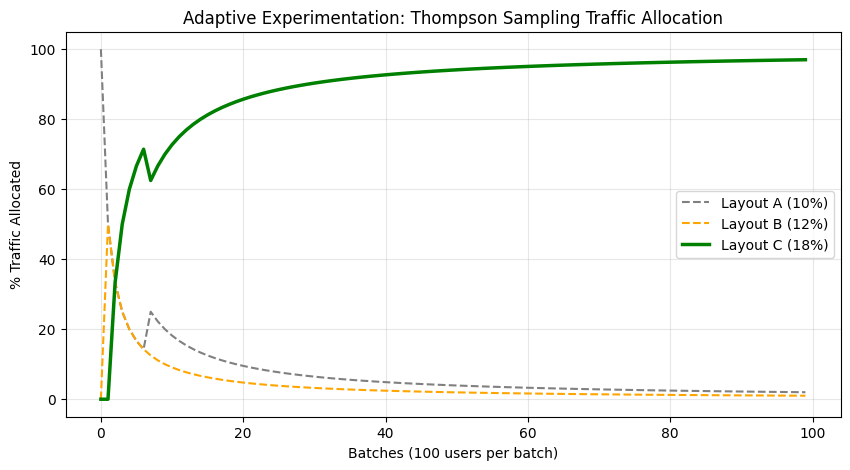

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# True underlying engagement rates for Layouts A, B, C
true_conversion_rates = [0.10, 0.12, 0.18]  # Layout C is the true winner
n_layouts = len(true_conversion_rates)

# Simulation parameters
total_users = 10000
batch_size = 100  # Update traffic allocation every 100 users

# Beta prior parameters for each layout (Alpha=Successes, Beta=Failures)
alphas = np.ones(n_layouts)
betas = np.ones(n_layouts)

# Track allocation history
allocation_history = []

for i in range(0, total_users, batch_size):
    # Thompson Sampling: sample from each layout's Beta posterior
    sampled_theta = [np.random.beta(alphas[j], betas[j]) for j in range(n_layouts)]

    # Choose layout with highest sampled value for the batch
    chosen_layout = np.argmax(sampled_theta)

    # Simulate user interactions for the batch
    conversions = np.random.binomial(batch_size, true_conversion_rates[chosen_layout])

    # Update Beta posteriors
    alphas[chosen_layout] += conversions
    betas[chosen_layout] += (batch_size - conversions)

    # Record current allocation counts
    allocation_history.append(alphas + betas - 2)

# Convert history for plotting
allocation_history = np.array(allocation_history)
traffic_percentages = (allocation_history.T / allocation_history.sum(axis=1)).T * 100

# Plot Traffic Allocation over time
plt.figure(figsize=(10, 5))
plt.plot(traffic_percentages[:, 0], label="Layout A (10%)", color="gray", linestyle="--")
plt.plot(traffic_percentages[:, 1], label="Layout B (12%)", color="orange", linestyle="--")
plt.plot(traffic_percentages[:, 2], label="Layout C (18%)", color="green", linewidth=2.5)

plt.title("Adaptive Experimentation: Thompson Sampling Traffic Allocation")
plt.xlabel("Batches (100 users per batch)")
plt.ylabel("% Traffic Allocated")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary & Key Takeaways

This series of exercises covered the complete lifecycle of experiment design and statistical decision-making, transitioning from traditional frequentist techniques to modern adaptive methodologies:

1. **Sample Size & Effect Size:** We established that small target effects require significantly larger sample sizes due to the inverse square relationship ($\text{Sample Size} \propto \frac{1}{\text{Effect Size}^2}$).
2. **Statistical Power Trade-offs:** Increasing statistical power from 80% to 90% reduces false negatives (Type II error) but requires a $\sim 34\%$ increase in sample size and testing runtime.
3. **Sequential Testing & Early Stopping:** Implementing adjusted boundaries (e.g., O'Brien-Fleming or Pocock) prevents the peeking problem, allowing teams to safely evaluate interim results without inflating false positives.
4. **Bayesian A/B Testing:** Bayesian methods reframe $p$-values into intuitive posterior probabilities ($P(B > A)$) and Expected Loss, providing actionable decision rules even under uncertainty.
5. **Adaptive Experimentation:** Multi-Armed Bandits (Thompson Sampling) dynamically balance exploration and exploitation, routing more traffic to top-performing variants early to minimize lost conversion opportunities.